# 02 — Supply & Demand Balance

**Evaluation: Insight** — How supply and demand constraints manifest in the data.

**Market invariant:** Production + Imports = Consumption + Exports. We explore how this balance shows up in the data and when imbalances correlate with price spikes.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_generation_pivot, load_total_load, load_flows_into, load_spot_price, SPOT_ZONES

## Production vs consumption (Germany)

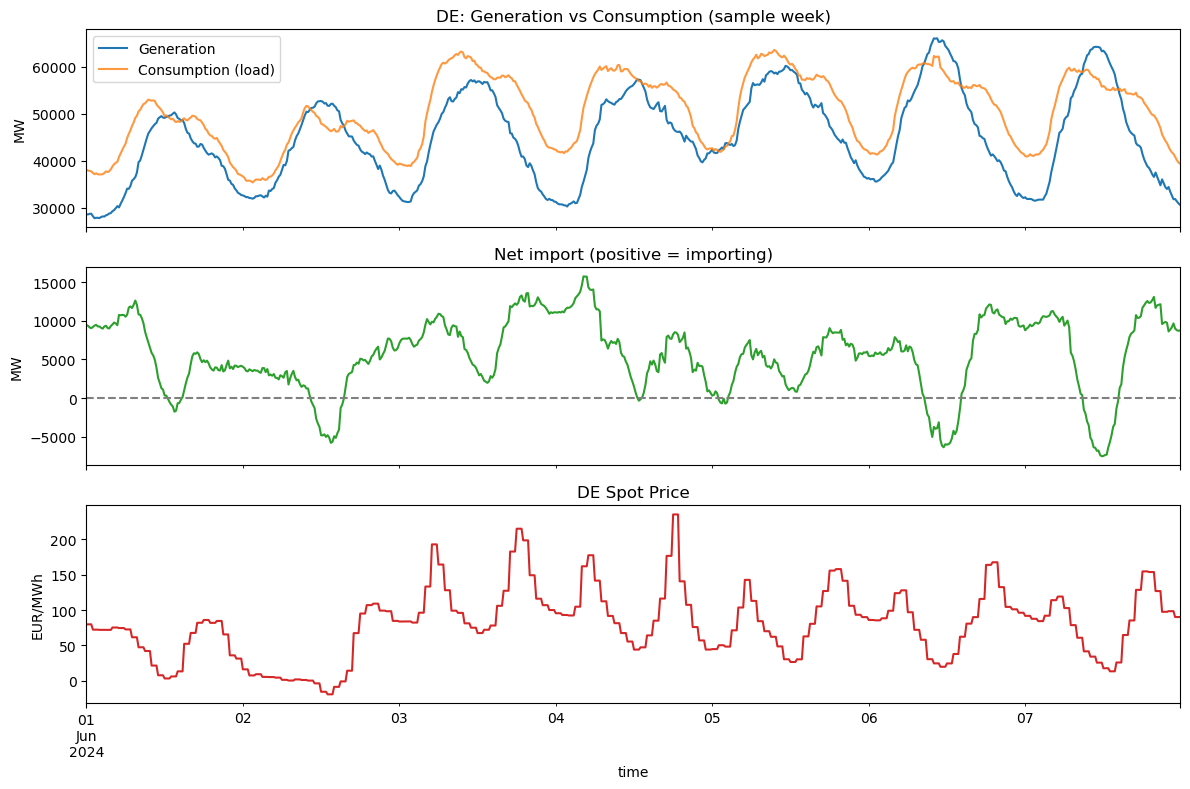

In [2]:
gen = load_generation_pivot("DE")
load = load_total_load("DE")

# Total generation = sum across types
gen["total_gen"] = gen.sum(axis=1)

# Align to 15min
gen_15 = gen["total_gen"].resample("15min").mean()
merged = pd.concat([gen_15.rename("generation"), load["load"].rename("consumption")], axis=1).dropna()

# Net import = consumption - generation (positive = importing)
merged["net_import"] = merged["consumption"] - merged["generation"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
sample = merged.loc["2024-06-01":"2024-06-07"]
sample["generation"].plot(ax=axes[0], label="Generation", color="C0")
sample["consumption"].plot(ax=axes[0], label="Consumption (load)", color="C1", alpha=0.8)
axes[0].set_ylabel("MW")
axes[0].legend()
axes[0].set_title("DE: Generation vs Consumption (sample week)")

sample["net_import"].plot(ax=axes[1], color="C2")
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_ylabel("MW")
axes[1].set_title("Net import (positive = importing)")

sp = load_spot_price("DE").reindex(sample.index).ffill()
sp["price"].plot(ax=axes[2], color="C3")
axes[2].set_ylabel("EUR/MWh")
axes[2].set_title("DE Spot Price")
plt.tight_layout()
plt.show()

## Correlation: net import vs spot price

Correlation (DE): net_import vs spot_price = 0.689
Interpretation: When Germany imports more (net_import > 0), price tends to be higher (scarcity).


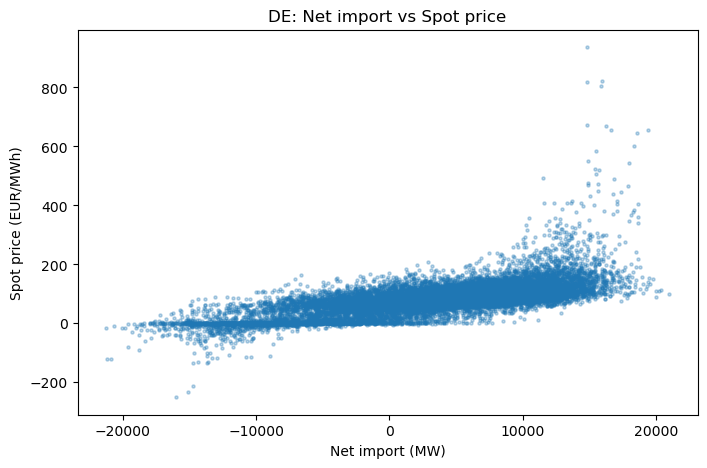

In [3]:
# Hourly alignment for spot price
merged_h = merged.resample("1h").mean()
sp_de = load_spot_price("DE")
join = merged_h.join(sp_de, how="inner")

corr = join["net_import"].corr(join["price"])
print(f"Correlation (DE): net_import vs spot_price = {corr:.3f}")
print("Interpretation: When Germany imports more (net_import > 0), price tends to be higher (scarcity).")

plt.figure(figsize=(8, 5))
plt.scatter(join["net_import"], join["price"], alpha=0.3, s=5)
plt.xlabel("Net import (MW)")
plt.ylabel("Spot price (EUR/MWh)")
plt.title("DE: Net import vs Spot price")
plt.show()

## Supply-demand gap and price extremes

In [4]:
# When is the gap largest? (consumption - generation)
join["gap"] = join["consumption"] - join["generation"]
high_gap = join.nlargest(100, "gap")
low_gap = join.nsmallest(100, "gap")

print("Top 5 hours with largest consumption > generation (scarcity):")
print(high_gap[["consumption", "generation", "gap", "price"]].head())
print("\nTop 5 hours with largest generation > consumption (surplus):")
print(low_gap[["consumption", "generation", "gap", "price"]].head())

Top 5 hours with largest consumption > generation (scarcity):
                           consumption  generation          gap   price
time                                                                   
2025-04-25 07:00:00+00:00  63367.50025  42364.8575  21002.64275   99.41
2025-04-25 05:00:00+00:00  58914.01375  38506.6625  20407.35125  113.39
2025-04-25 06:00:00+00:00  62136.12025  41877.5300  20258.59025  111.00
2025-07-21 07:00:00+00:00  60691.16100  40657.1515  20034.00950  109.64
2025-04-25 08:00:00+00:00  64347.04500  44358.3375  19988.70750   88.17

Top 5 hours with largest generation > consumption (surplus):
                           consumption  generation         gap   price
time                                                                  
2024-10-13 11:00:00+00:00   49936.6050  71221.0375 -21284.4325  -15.16
2024-05-01 11:00:00+00:00   41995.2425  63167.6275 -21172.3850 -120.00
2024-05-01 12:00:00+00:00   40698.1800  61564.9000 -20866.7200 -120.07
2024-10-13 10:00: